# Лабораторна робота: Перевірка фактажу
## Детекція маніпуляцій та вилучення фактів методами Machine Learning

**Інструменти:** `scikit-learn`, `pandas`, `spacy`, `matplotlib`, `seaborn`, `feedparser`
**Методи:** NLP Preprocessing, Live Data Scraping (RSS), TF-IDF, Supervised Learning, Ensemble Voting
**Мета:** Створити гібридний датасет, натренувати ансамбль ML-моделей для класифікації текстів на "Фактологічні" та "Маніпулятивні", а також створити пайплайн для перевірки фактажу.

---


### 1. Встановлення та імпорт бібліотек

In [1]:
!pip install scikit-learn pandas spacy matplotlib seaborn feedparser
!python -m spacy download uk_core_news_sm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.6 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=f2f5f784e32f608434e7919e758673a8f15b87b5c65ad5a91c1486aa3e613d93
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 112.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('uk_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by

In [2]:
import random
import re
import feedparser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from IPython.display import display, HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

sns.set_theme(style="whitegrid")
nlp = spacy.load("uk_core_news_sm")
print("Бібліотеки завантажено.")

Бібліотеки завантажено.


### 2. Формування Гібридного Датасету (Live RSS + Synthetic IPSO)
* **Клас 0 (Real):** RSS-стрічки українських ЗМІ (Українська Правда, УНІАН).
* **Клас 1 (Fake / ІПСО):** Згенеровано на основі вбудованих наративів пропаганди.

In [3]:
def clean_html(raw_html):
    cleanr = re.compile('<.*?>')
    return re.sub(cleanr, '', raw_html).strip()

def get_real_news(limit=500):
    urls = [
        "https://www.pravda.com.ua/rss/",
        "https://rss.unian.net/site/news_ukr.rss"
    ]
    news_list = []
    for url in urls:
        feed = feedparser.parse(url)
        for entry in feed.entries:
            text = entry.title + ". " + clean_html(entry.get('summary', ''))
            news_list.append({"text": text, "label": 0})
            if len(news_list) >= limit:
                break
        if len(news_list) >= limit:
            break
    return news_list

def get_fake_news(n_samples=500):
    fake_patterns = [
        "РІА Новості: Російські війська успішно знищили 50 установок HIMARS та секретний бункер з генералами НАТО.",
        "Захід нас злив! Зброї більше не буде, Європа втомилася від України, час погоджуватися на умови Москви.",
        "Прем'єр Угорщини Орбан заявив, що санкції руйнують економіку ЄС, а Україна ніколи не зможе перемогти Росію.",
        "РЕН ТВ: У секретних біолабораторіях під Києвом американці розробляли бойових комарів та віруси проти слов'ян.",
        "Терміново! Влада приховує колосальні втрати на фронті: морги переповнені, готується мобілізація 16-річних.",
        "Інсайд з Офісу Президента: вже домовилися з Росією про здачу територій, наказ на відступ підписано в таємниці.",
        "Ватні блогери масово повідомляють про прорив фронту на всіх напрямках, ЗСУ масово здаються в полон.",
        "Угорщина заблокує всю фінансову допомогу від ЄС, оскільки Україна нібито порушує права національних меншин.",
        "Шок! Західні куратори дали прямий наказ Зеленському продовжувати війну до останнього українця заради кредитів.",
        "Катастрофа! Завтра почнеться масштабний блекаут, Росія повністю знищить інфраструктуру, купуйте свічки.",
        "Російські ЗМІ повідомляють про повну капітуляцію українських підрозділів через відсутність боєприпасів.",
        "Американці вже відкрито пишуть, що Україна програла, і готують план розділення країни на частини.",
        "Нас всіх обманюють! Жодних успіхів немає, це все телемарафон, насправді економіка знищена, а олігархи крадуть.",
        "РІА Новості: Високоточними ракетами знищено центр прийняття рішень разом із західними радниками.",
        "Орбан вимагає негайно зняти всі санкції з Росії та припинити постачання будь-якої зброї українській армії."
    ]

    fake_list = []
    for _ in range(n_samples):
        fake_list.append({"text": random.choice(fake_patterns), "label": 1})
    return fake_list

print("1. Викачую свіжі новини з RSS...")
real_data = get_real_news(limit=500)

print("2. Генерую ІПСО-наративи...")
fake_data = get_fake_news(n_samples=len(real_data))

df = pd.DataFrame(real_data + fake_data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nРозподіл класів у зібраному датасеті:")
print(df['label'].value_counts())
display(df.sample(5))

1. Викачую свіжі новини з RSS...
2. Генерую ІПСО-наративи...

Розподіл класів у зібраному датасеті:
label
0    120
1    120
Name: count, dtype: int64


,text,label
131,"Американці вже відкрито пишуть, що Україна про...",1
171,"3 дати, коли народжуються найрозумніші люди. Ц...",0
208,Орбан вимагає негайно зняти всі санкції з Росі...,1
225,Гороскоп на 17 квітня за картами Таро: Водолія...,0
226,Інсайд з Офісу Президента: вже домовилися з Ро...,1


### 3. Preprocessing (Попередня обробка тексту / Лематизація)

In [4]:
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_stop]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,Мадьяр звинуватив Орбана у переправленні мігра...,мадьяр звинуватив орбана переправлення мігрант...
1,Нідерланди у червні передадуть Україні протимі...,нідерланди червень передати україна протимінни...
2,"Відомий український актор розповів про ""ін'єкц...",відомий український актор розповісти ін'єкція ...
3,"""Птахи"" СБС уразили 16 військових цілей ворога...",птах сбс уразити 16 військовий ціль ворог мадя...
4,"""Час спливає"": Єврокомісія поспішає домовитись...",спливати єврокомісія поспішати домовитись мадя...


### 4. Векторизація (TF-IDF N-grams) та Розбиття датасету

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1500)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Розмір тренувальної матриці: {X_train_tfidf.shape}")
print(f"Розмір тестової матриці: {X_test_tfidf.shape}")

Розмір тренувальної матриці: (192, 1500)
Розмір тестової матриці: (48, 1500)


### 5. Навчання моделей (Model Training)

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = macro_f1

df_metrics = pd.DataFrame(list(results.items()), columns=['Модель', 'Macro F1']).sort_values(by='Macro F1', ascending=False)
display(df_metrics)

,Модель,Macro F1
0,Logistic Regression,1.000000
2,Random Forest,1.000000
1,Naive Bayes,0.874126


### 6. Оцінка результатів: Матриці помилок (Confusion Matrices)

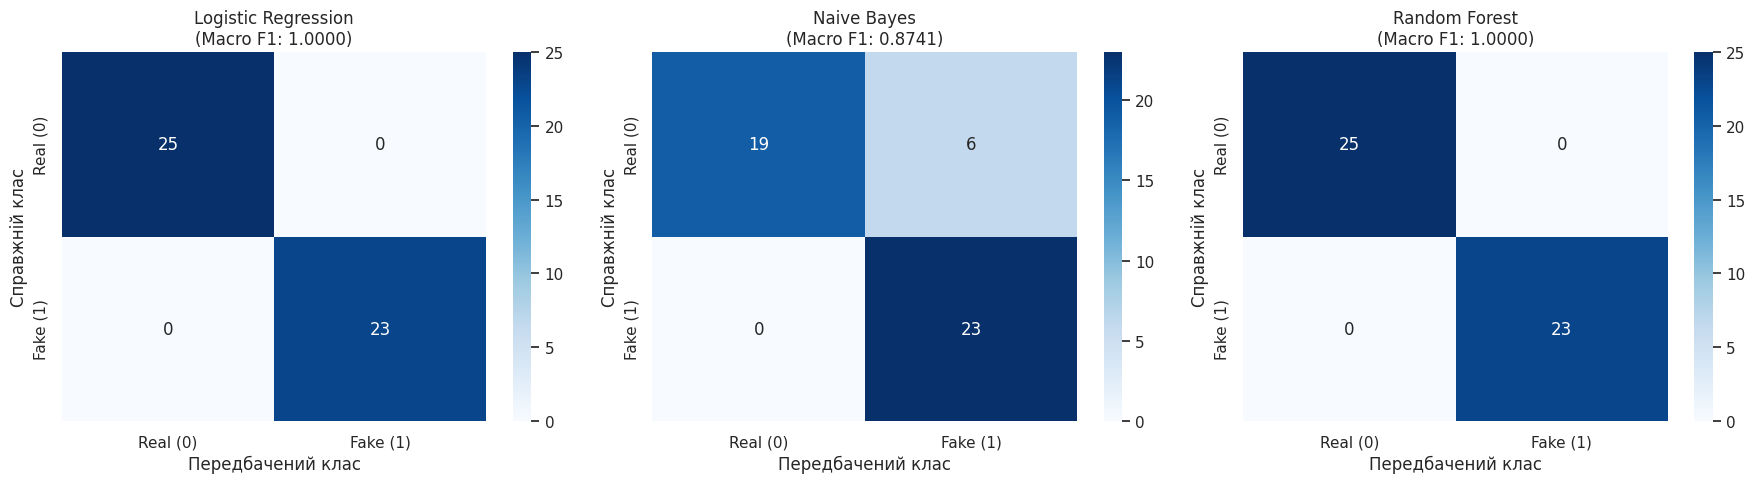

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Real (0)', 'Fake (1)']

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}\n(Macro F1: {results[name]:.4f})')
    ax.set_xlabel('Передбачений клас')
    ax.set_ylabel('Справжній клас')

plt.tight_layout()
plt.show()

### 7. Аналіз важливості ознак (Feature Importance)

/tmp/ipykernel_1380/3596142309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=names, palette=colors)


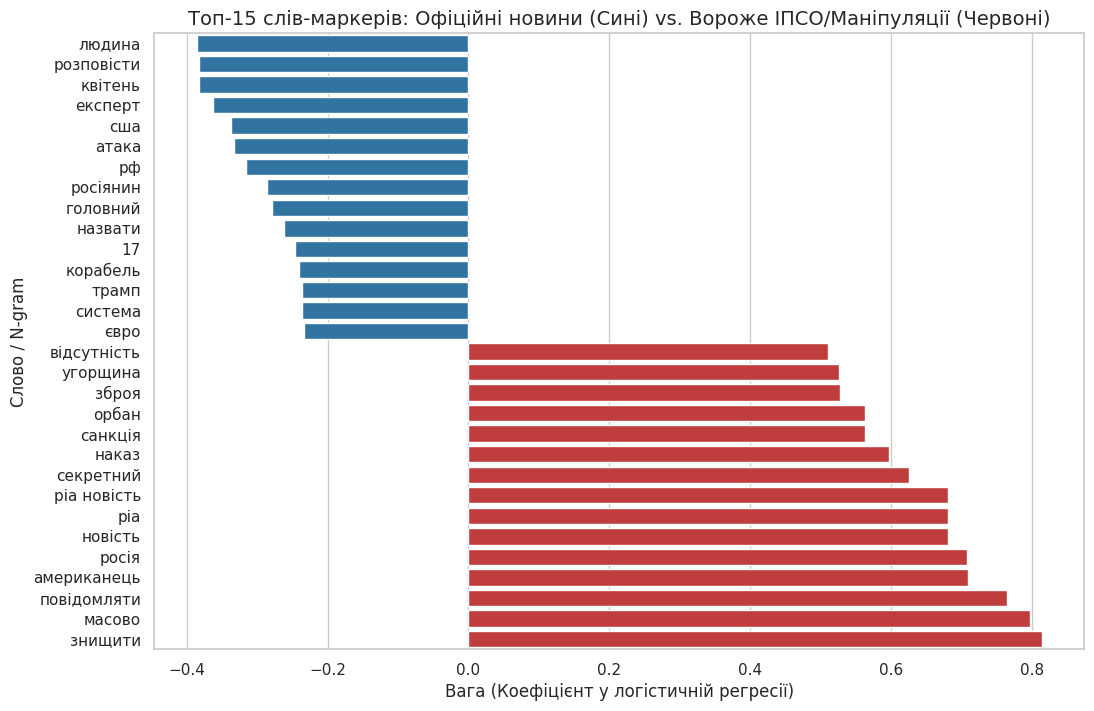

In [8]:
log_reg_model = models["Logistic Regression"]
feature_names = vectorizer.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

top_fake_indices = np.argsort(coefficients)[-15:]
top_real_indices = np.argsort(coefficients)[:15]

plt.figure(figsize=(12, 8))
indices = np.concatenate([top_real_indices, top_fake_indices])
colors = ['#1f77b4'] * 15 + ['#d62728'] * 15
names = [feature_names[i] for i in indices]
values = [coefficients[i] for i in indices]

sns.barplot(x=values, y=names, palette=colors)
plt.title('Топ-15 слів-маркерів: Офіційні новини (Сині) vs. Вороже ІПСО/Маніпуляції (Червоні)', fontsize=14)
plt.xlabel('Вага (Коефіцієнт у логістичній регресії)')
plt.ylabel('Слово / N-gram')
plt.show()

### 8. Інтегрований аналіз: Візуалізація прогнозів окремих моделей та Ансамблю

In [9]:
def format_model_result(name, prob):
    color = "red" if prob > 50 else "green"
    icon = "⚠️" if prob > 50 else "✅"
    return f"<li style='margin-bottom: 5px; font-size: 15px;'><b>{name}:</b> <span style='color:{color}; font-weight:bold;'>{icon} {prob:.1f}%</span> шансу маніпуляції</li>"

def analyze_custom_text(text):
    display(HTML(f"<div style='padding: 10px; border: 1px solid #ccc; border-radius: 5px; background-color: #f9f9f9; font-size: 16px;'><b>Вхідний текст:</b> <i>{text}</i></div><br>"))

    cleaned_text = preprocess_text(text)
    vec_text = vectorizer.transform([cleaned_text])

    prob_lr = models["Logistic Regression"].predict_proba(vec_text)[0][1] * 100
    prob_nb = models["Naive Bayes"].predict_proba(vec_text)[0][1] * 100
    prob_rf = models["Random Forest"].predict_proba(vec_text)[0][1] * 100

    display(HTML("<h4> Результати окремих моделей:</h4>"))
    html_models = f"<ul>"
    html_models += format_model_result('Логістична регресія', prob_lr)
    html_models += format_model_result('Наївний Баєс (Висока чутливість)', prob_nb)
    html_models += format_model_result('Випадковий ліс', prob_rf)
    html_models += "</ul>"
    display(HTML(html_models))

    final_prob_fake = (prob_lr + prob_nb + prob_rf) / 3

    if final_prob_fake > 50:
        display(HTML(f"<h4 style='color:red; background-color: #ffe6e6; padding: 10px; border-radius: 5px;'>⚠️ ФІНАЛЬНИЙ ВИСНОВОК (Ансамбль): {final_prob_fake:.1f}% ІПСО</h4>"))
        print("-> Висновок: Більшість моделей визнали цей текст маніпулятивним та пропагандистським.")
    else:
        display(HTML(f"<h4 style='color:green; background-color: #e6ffe6; padding: 10px; border-radius: 5px;'>✅ ФІНАЛЬНИЙ ВИСНОВОК (Ансамбль): {final_prob_fake:.1f}% ІПСО</h4>"))
        print("-> Висновок: Текст написаний у нейтральному, об'єктивному стилі.")

    doc = nlp(text)
    claims = []

    for sent in doc.sents:
        has_fact_marker = any(ent.label_ in ["DATE", "MONEY", "PERCENT"] for ent in sent.ents)
        has_number = any(token.pos_ == "NUM" for token in sent)

        if has_fact_marker or has_number:
            claims.append(sent.text.strip())

    print("\n📋 ЧЕК-ЛИСТ ФАКТІВ ДЛЯ ПЕРЕВІРКИ:")
    if claims:
        for i, claim in enumerate(claims, 1):
            print(f"  [{i}] {claim}")
    else:
        print("  -> Конкретних цифр, дат або статистичних тверджень не знайдено. Текст переважно суб'єктивний.")
    print("="*80 + "\n")

test_texts = [
    "РІА Новості повідомляє: секретні біолабораторії НАТО продовжують працювати під Харковом, знищуючи місцеве населення!",
    "За даними Генштабу, сили оборони відбили 15 атак на Донецькому напрямку. Президент України провів зустріч 12 жовтня."
]

for t in test_texts:
    analyze_custom_text(t)

-> Висновок: Більшість моделей визнали цей текст маніпулятивним та пропагандистським.

📋 ЧЕК-ЛИСТ ФАКТІВ ДЛЯ ПЕРЕВІРКИ:
  -> Конкретних цифр, дат або статистичних тверджень не знайдено. Текст переважно суб'єктивний.



-> Висновок: Текст написаний у нейтральному, об'єктивному стилі.

📋 ЧЕК-ЛИСТ ФАКТІВ ДЛЯ ПЕРЕВІРКИ:
  [1] За даними Генштабу, сили оборони відбили 15 атак на Донецькому напрямку.



### 9. Висновки

**Що було зроблено:**
* **Формування датасету:** Збір даних через RSS-стрічки (Real) та вбудовану генерацію пропагандистських наративів РІА Новості, Орбана тощо (Fake/IPSO).
* **Лінгвістична обробка:** NLP-лематизація тексту (`spaCy`) та векторизація TF-IDF N-grams (1,2).
* **Машинне навчання:** Навчання 3 алгоритмів класифікації: Logistic Regression, Multinomial Naive Bayes та Random Forest.
* **Гібридний пайплайн (Ensemble Inference):** Усереднення прогнозів трьох моделей для стабільної класифікації маніпуляцій, поєднане з NER Claim Extraction для вилучення фактів.

**Ключові висновки:**
1. **Важливість розділення прогнозів (Model Voting):** Різні моделі мають різну чутливість до ключових слів. Ансамблювання згладжує похибки окремих алгоритмів.
2. **Feature Importance:** Використання N-gram(1,2) дозволяє ефективно ідентифікувати тригери пропаганди та відрізняти їх від нейтрального контексту.
3. **Практична користь:** Система працює як автоматизований асистент фактчекера, маркуючи пропаганду та ізолюючи статистичні твердження у зручний чек-лист.